In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION PROJECT
# Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Target: Class
# 0 = Genuine transaction, 1 = Fraud transaction
# ============================================================

In [2]:
# STEP 1: Install required libraries

!pip install -q kagglehub imbalanced-learn xgboost

In [3]:
# STEP 2: Import libraries

import os
import glob
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [4]:
# STEP 3: Download dataset directly from Kaggle

# Replace with your Kaggle username and key
os.environ["KAGGLE_USERNAME"] = "sauravmakde"
os.environ["KAGGLE_KEY"] = "KGAT_932b4c963405d733b4d8f8d5375d6a05"

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
df = pd.read_csv(csv_files[0])

print("Dataset shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# ============================================================
# PART A - DATA ANALYSIS
# ============================================================

In [5]:
# STEP 4: Data understanding

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns)

df.head()

Rows: 284807
Columns: 31

Column names:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# STEP 5: Dataset profiling

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
# STEP 6: Target variable distribution

print(df["Class"].value_counts())
print("\nPercentage distribution:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


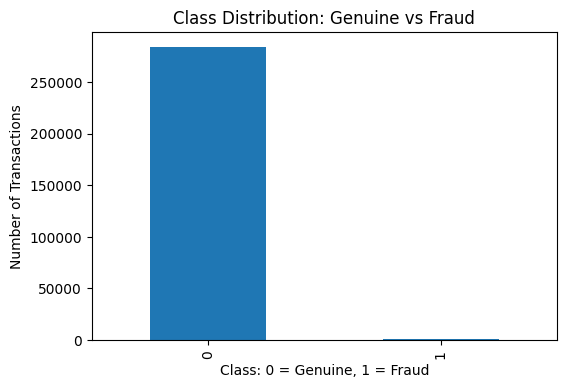

In [9]:
# Visualization: Fraud vs Genuine transactions

plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Genuine vs Fraud")
plt.xlabel("Class: 0 = Genuine, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
# STEP 7: Missing value treatment

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# If no missing values, no treatment required

Series([], dtype: int64)


In [11]:
# STEP 8: Duplicate handling

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 1081
Shape after removing duplicates: (283726, 31)


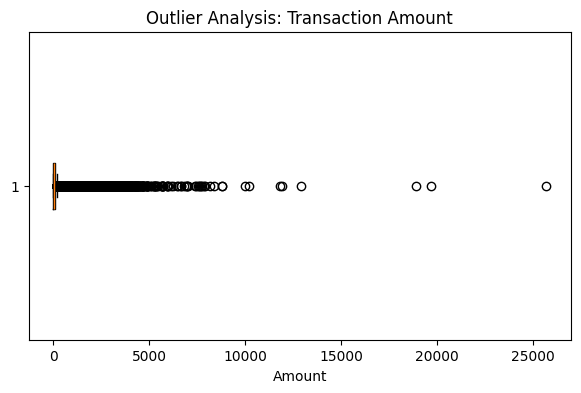

In [12]:
# STEP 9: Outlier analysis for Amount

plt.figure(figsize=(7,4))
plt.boxplot(df["Amount"], vert=False)
plt.title("Outlier Analysis: Transaction Amount")
plt.xlabel("Amount")
plt.show()

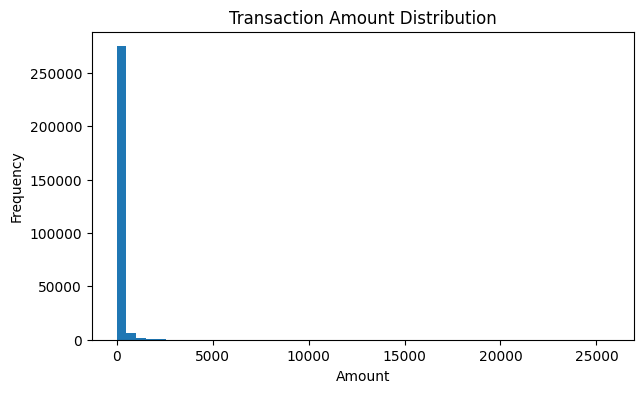

In [13]:
# Amount distribution

plt.figure(figsize=(7,4))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

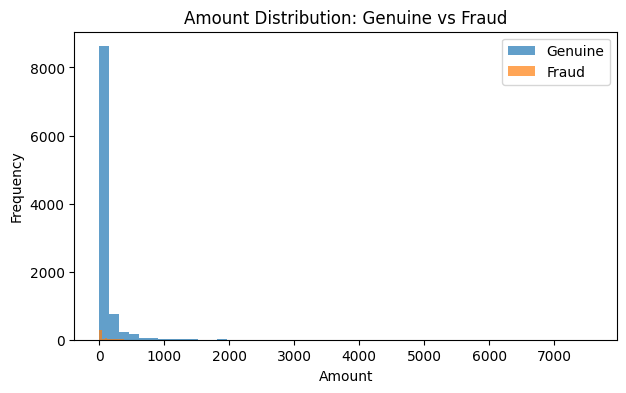

In [14]:
# Fraud vs Non-Fraud amount comparison

plt.figure(figsize=(7,4))
df[df["Class"] == 0]["Amount"].sample(10000, random_state=42).plot(kind="hist", bins=50, alpha=0.7, label="Genuine")
df[df["Class"] == 1]["Amount"].plot(kind="hist", bins=50, alpha=0.7, label="Fraud")
plt.title("Amount Distribution: Genuine vs Fraud")
plt.xlabel("Amount")
plt.legend()
plt.show()

In [15]:
# STEP 10: Feature engineering

# Convert Time from seconds to hours
df["Hour"] = (df["Time"] / 3600) % 24

# Log transform Amount to reduce skewness
df["Log_Amount"] = np.log1p(df["Amount"])

df[["Time", "Hour", "Amount", "Log_Amount", "Class"]].head()

,Time,Hour,Amount,Log_Amount,Class
0,0.0,0.000000,149.62,5.014760,0
1,0.0,0.000000,2.69,1.305626,0
2,1.0,0.000278,378.66,5.939276,0
3,1.0,0.000278,123.50,4.824306,0
4,2.0,0.000556,69.99,4.262539,0


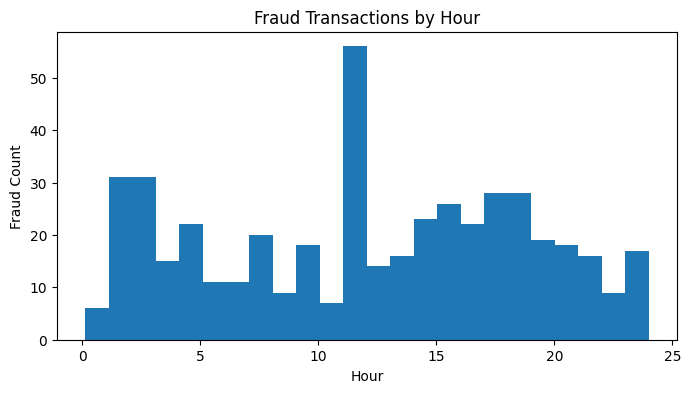

In [16]:
# Visualization: Fraud by hour

plt.figure(figsize=(8,4))
df[df["Class"] == 1]["Hour"].plot(kind="hist", bins=24)
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")
plt.show()

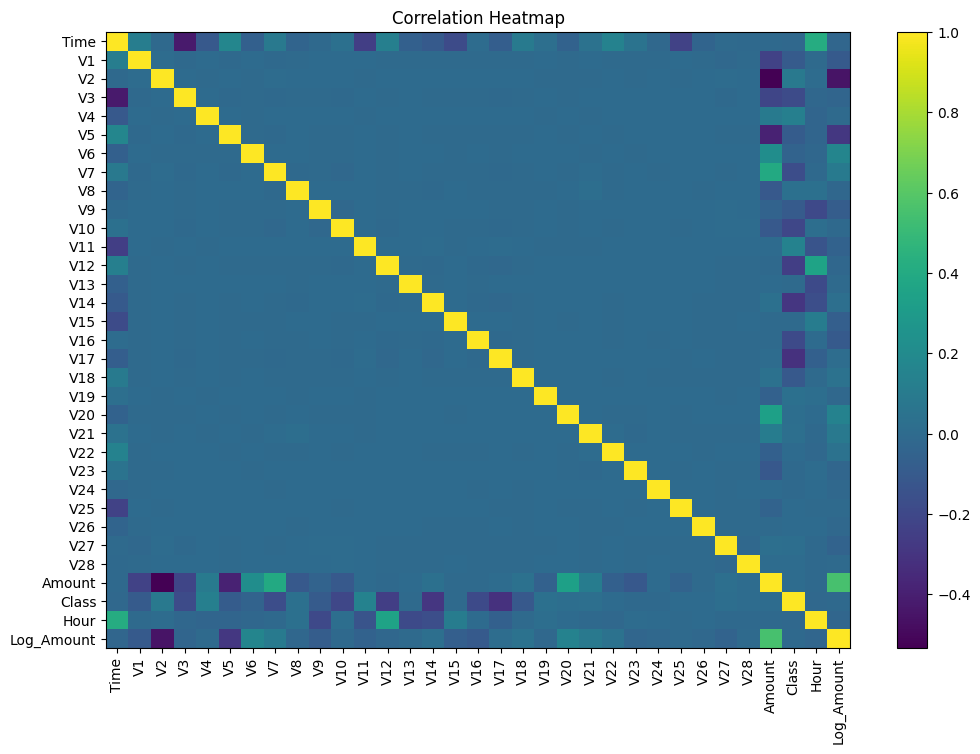

In [17]:
# STEP 11: Correlation analysis

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [18]:
# Features most correlated with fraud class

class_corr = corr["Class"].sort_values(ascending=False)
print(class_corr)

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
Log_Amount   -0.007798
Time         -0.012359
Hour         -0.016696
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64


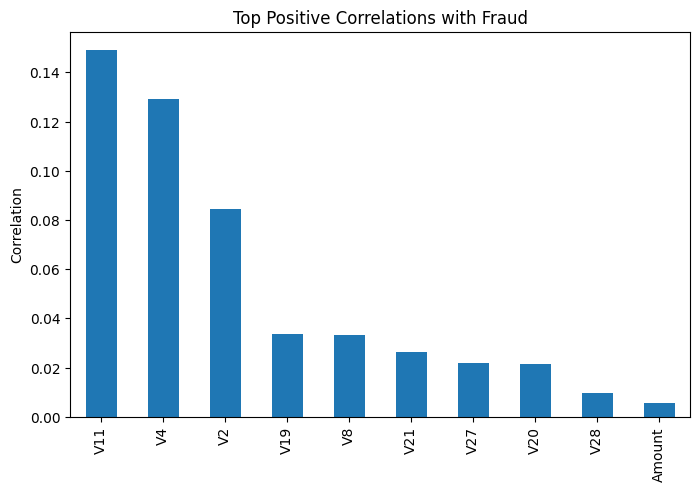

In [19]:
plt.figure(figsize=(8,5))
class_corr.drop("Class").head(10).plot(kind="bar")
plt.title("Top Positive Correlations with Fraud")
plt.ylabel("Correlation")
plt.show()

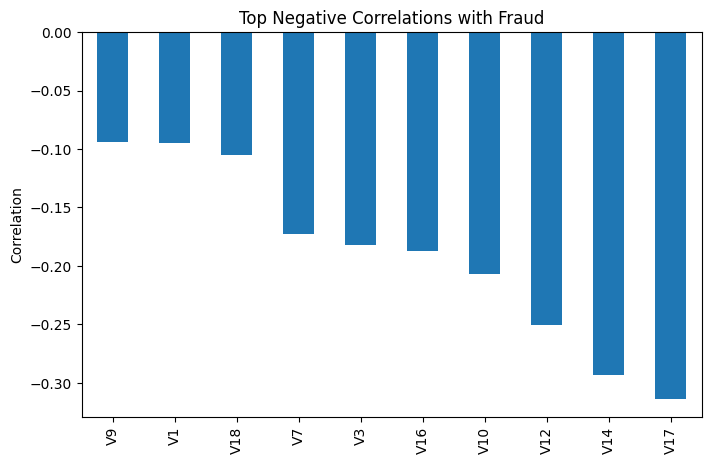

In [20]:
plt.figure(figsize=(8,5))
class_corr.drop("Class").tail(10).plot(kind="bar")
plt.title("Top Negative Correlations with Fraud")
plt.ylabel("Correlation")
plt.show()

# ============================================================
# PART B - MODEL DEVELOPMENT
# ============================================================

In [21]:
# STEP 12: Define features and target

X = df.drop(["Class"], axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 32)
Target shape: (283726,)


In [22]:
# STEP 13: Dataset splitting

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training class distribution:")
print(y_train.value_counts())
print("Testing class distribution:")
print(y_test.value_counts())

Training data: (226980, 32)
Testing data: (56746, 32)
Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


# STEP 14: Feature scaling + SMOTE + Model pipeline

# Fraud data is highly imbalanced, so we use SMOTE only on training data.

In [23]:
# STEP 15: Model 1 - Logistic Regression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [24]:
# STEP 16: Model 2 - Random Forest

rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [25]:
# STEP 17: Model 3 - XGBoost

xgb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [26]:
# STEP 18: Performance evaluation function

def evaluate_model(model_name, y_true, y_pred, y_prob):
    print("="*60)
    print(model_name)
    print("="*60)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("Average Precision Score:", average_precision_score(y_true, y_prob))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [27]:
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

Logistic Regression
Accuracy: 0.9731963486413139
Precision: 0.052135678391959796
Recall: 0.8736842105263158
F1 Score: 0.0983995257854179
ROC-AUC: 0.9653299193863815
Average Precision Score: 0.6849786545486077

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746


Confusion Matrix:
[[55142  1509]
 [   12    83]]
Random Forest
Accuracy: 0.998766432876326
Precision: 0.5984251968503937
Recall: 0.8
F1 Score: 0.6846846846846847
ROC-AUC: 0.9765761555749004
Average Precision Score: 0.7717069679546924

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.60      0.80      0.68        95

    accuracy     

In [28]:
# STEP 19: Model performance comparison report

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "Avg Precision": [
        average_precision_score(y_test, lr_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Avg Precision
0,Logistic Regression,0.973196,0.052136,0.873684,0.098400,0.965330,0.684979
1,Random Forest,0.998766,0.598425,0.800000,0.684685,0.976576,0.771707
2,XGBoost,0.997921,0.435754,0.821053,0.569343,0.972223,0.798198


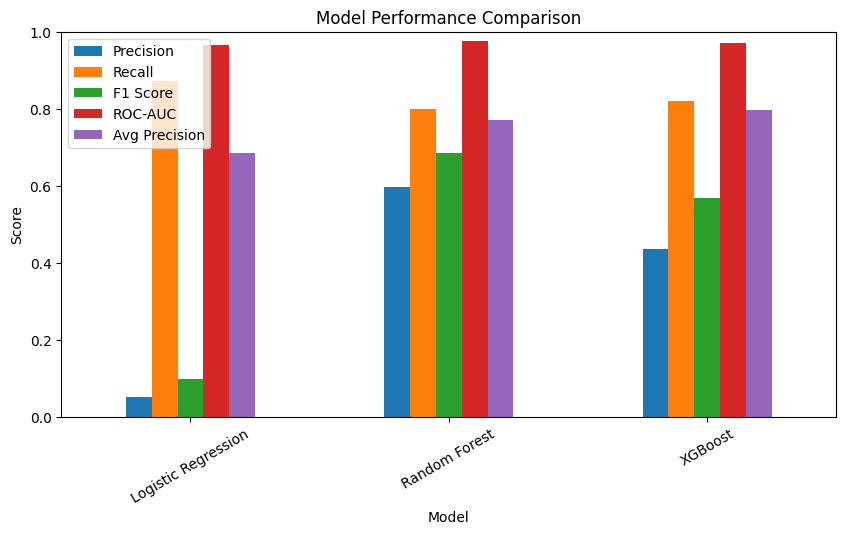

In [29]:
# Visualization: Model performance comparison

metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC", "Avg Precision"]

results.set_index("Model")[metrics].plot(kind="bar", figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

Best model based on F1 Score: Random Forest


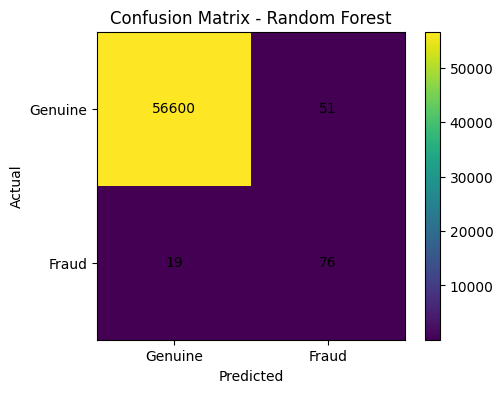

In [30]:
# STEP 20: Confusion matrix visualization for best model

best_model_name = results.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
print("Best model based on F1 Score:", best_model_name)

if best_model_name == "Logistic Regression":
    best_pred = lr_pred
    best_prob = lr_prob
elif best_model_name == "Random Forest":
    best_pred = rf_pred
    best_prob = rf_prob
else:
    best_pred = xgb_pred
    best_prob = xgb_prob

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
plt.xticks([0,1], ["Genuine", "Fraud"])
plt.yticks([0,1], ["Genuine", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

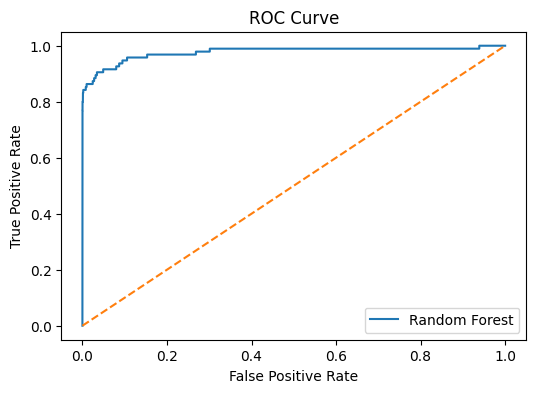

In [31]:
# STEP 21: ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, best_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"{best_model_name}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

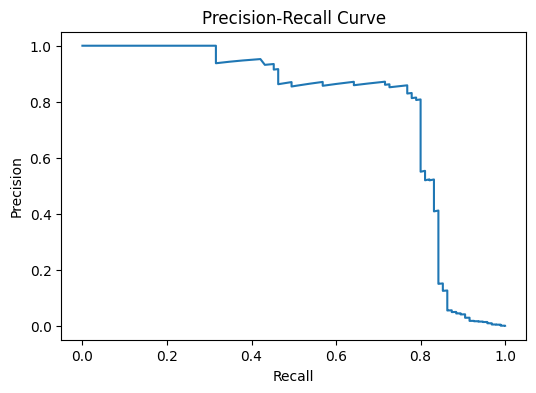

In [32]:
# STEP 22: Precision-Recall Curve

precision, recall, thresholds = precision_recall_curve(y_test, best_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [33]:
# STEP 23: Hyperparameter tuning for Random Forest

param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

was taking longer tome thats why this code

In [ ]:
# STEP 23: Fast Hyperparameter Tuning for Random Forest

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 10, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=5,              # only 5 combinations
    scoring="f1",
    cv=2,                  # faster than cv=3
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV F1 score:", random_search.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


In [ ]:
# STEP 24: Evaluate tuned model

tuned_model = grid.best_estimator_

tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

evaluate_model("Tuned Random Forest", y_test, tuned_pred, tuned_prob)

In [ ]:
# STEP 25: Feature importance from tuned Random Forest

rf_model = tuned_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"].head(15), feature_importance["Importance"].head(15))
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

# ============================================================
# PART C - INTERPRETATION & DECISION MAKING
# ============================================================

In [ ]:
# STEP 26: Business interpretation report

business_report = f"""
BUSINESS INTERPRETATION REPORT

1. Business Problem Solved:
The financial institution wanted to identify suspicious transactions that may indicate fraudulent activity.
This project builds a machine learning model that classifies transactions as genuine or fraudulent.

2. Most Important Variables:
The important predictors are mainly PCA-transformed features such as V1 to V28, along with Amount, Time, Hour, and Log_Amount.
Since V1 to V28 are anonymized PCA features, their exact business meaning is hidden, but they strongly capture transaction behavior patterns.

Top important features from the model:
{feature_importance.head(10).to_string(index=False)}

3. Key Insights:
- Fraud cases are very rare compared to genuine transactions.
- Accuracy alone is not enough because the dataset is highly imbalanced.
- Recall is very important because missing a fraud transaction can cause financial loss.
- Precision is also important because too many false alarms can disturb genuine customers.
- The best model should balance recall and precision using F1 Score and Precision-Recall AUC.

4. Deployment Risks:
- False negatives: fraud transactions predicted as genuine.
- False positives: genuine customers wrongly blocked.
- Model drift: fraud patterns change over time.
- Data privacy risk because transaction data is sensitive.
- Overdependence on model without human review may increase operational risk.

5. Final Recommendation to Management:
Use the tuned model as a fraud risk scoring system, not as a fully automatic blocking system.
High-risk transactions should be sent for manual verification.
Medium-risk transactions should trigger OTP or additional authentication.
Low-risk transactions can be approved automatically.
The model should be monitored and retrained regularly using new transaction data.
"""

print business_report

In [ ]:
print(business_report)

In [ ]:
# STEP 27: Risk management strategy

risk_strategy = """
RISK MANAGEMENT STRATEGY

1. Real-Time Fraud Scoring:
Every transaction should receive a fraud probability score from the model.

2. Risk-Based Decision Rules:
- Probability >= 0.80: Block temporarily and send for manual verification.
- Probability between 0.50 and 0.80: Ask for OTP or additional authentication.
- Probability below 0.50: Allow transaction.

3. Human-in-the-Loop Review:
Fraud analysts should review high-risk cases before final rejection.

4. Customer Protection:
Notify customers immediately when suspicious activity is detected.

5. Model Monitoring:
Track recall, precision, F1-score, false positives, false negatives, and fraud loss amount.

6. Regular Retraining:
Retrain the model monthly or quarterly because fraud behavior changes over time.

7. Compliance and Privacy:
Store transaction data securely and follow banking data protection rules.

FINAL DECISION:
Deploy the model as an early warning fraud detection system.
Do not fully automate rejection in the first phase.
Use model predictions to support fraud analysts and reduce financial loss.
"""

print(risk_strategy)

In [ ]:
# STEP 28: Final decision-making summary table

summary_table = pd.DataFrame({
    "Area": [
        "Business Problem",
        "Best Model",
        "Main Metric",
        "Why Accuracy Is Not Enough",
        "Risk Strategy",
        "Final Recommendation"
    ],
    "Decision Summary": [
        "Detect suspicious credit card transactions",
        best_model_name,
        "F1 Score, Recall, Precision-Recall AUC",
        "Fraud cases are very rare, so high accuracy can be misleading",
        "Use probability-based fraud scoring with manual review",
        "Deploy as decision-support system with monitoring and retraining"
    ]
})

summary_table

In [ ]:
# STEP 29: Save reports as CSV files

results.to_csv("model_performance_report.csv", index=False)
feature_importance.to_csv("feature_importance_report.csv", index=False)
summary_table.to_csv("business_decision_summary.csv", index=False)

print("Reports saved successfully.")

In [ ]:
Correctly identifies most fraudulent transactions.
Produces fewer false alarms compared to Logistic Regression and XGBoost.
Provides the best balance between fraud detection and customer experience.

Model Used

TF-IDF + Linear SVM (Support Vector Machine)

Why This Model?
The dataset contains text reviews, so first we converted text into numerical features using TF-IDF Vectorization.
Linear SVM is one of the best algorithms for text classification because:
Works well with high-dimensional text data.
Provides high accuracy.
Handles large datasets efficiently.
Performs better than many traditional models for sentiment analysis.
Outcome
The model classified learner feedback into:
Positive Sentiment (Satisfied Learners)
Negative Sentiment (Dissatisfied Learners)
Business Outcome
Automatically analyzes thousands of feedback messages.
Identifies learner satisfaction levels.
Detects negative feedback requiring attention.
Helps management improve course content, teaching quality, and learner experience.
Reduces manual effort in reviewing feedback.
Final Recommendation

Deploy the TF-IDF + Linear SVM model as a feedback monitoring system. Use it to track learner sentiment, identify problem areas early, and support data-driven decisions for improving learning outcomes.